In [1]:
import glob
from scalesurfer.config import DATA_PATH, MODULE_PATH, SEED
from scalesurfer.experiments import build_v8_split_from_root
from scalesurfer import ScaleSurfer

In [12]:
# small test dataset
ds = {
    'ds004589': '/home/rph/convolutional_ar/segmentation/data/openneuro_test_set_raw/files/ds004589/sub-140/anat/sub-140_T1w.nii.gz',
    'ds002878': '/home/rph/convolutional_ar/segmentation/data/openneuro_test_set_raw/files/ds002878/sub-094BPAF1211010/ses-1/anat/sub-094BPAF1211010_ses-1_T1w.nii.gz',
    'ds003720': '/home/rph/convolutional_ar/segmentation/data/openneuro_test_set_raw/files/ds003720/sub-005/anat/sub-005_T1w.nii',
    'ds002168': '/home/rph/convolutional_ar/segmentation/data/openneuro_test_set_raw/files/ds002168/sub-1516/anat/sub-1516_T1w.nii.gz',
    'ds001241': '/home/rph/convolutional_ar/segmentation/data/openneuro_test_set_raw/files/ds001241/sub-14/anat/sub-14_T1w.nii.gz'
}

In [14]:
# images
images = list(ds.values())

# names of the ouput dirs in subject_dir
subjects = list(ds.keys())

# initialize object
surfer = ScaleSurfer(
    images,
    subjects,
    DATA_PATH / "subjects_dir",
    batch_size=2,
    n_jobs_cpu=-1,
    device="cuda",
    conform_backend="nibabel",
    overwrite=True
)

surfer.prepare_images()  # saves subject_dir/*/mri/orig.{pt, mgz}
surfer.predict_volumes() # saves subject_dir/*/mri/aparc+aseg.pt

Conforming images:   0%|          | 0/5 [00:00<?, ?it/s]

[scalesurfer] prepare_images: 4.5s total, 1.10 img/s (0.9s/img) for 5 subject(s)


Predicting volumes:   0%|          | 0/3 [00:00<?, ?it/s]

[scalesurfer] predict_volumes: 9.5s total, 0.53 img/s (1.9s/img) for 5 subject(s)


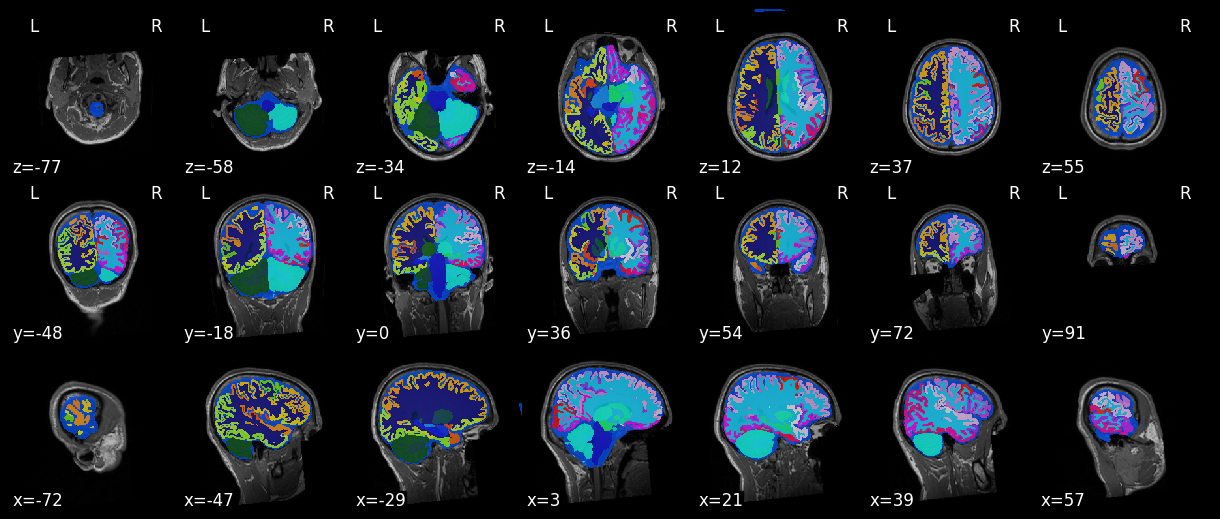

In [15]:
surfer.plot_volume('ds004589')